# Fraud Detection â€” ML Pipeline

## Phase 1: Business Understanding (Ch. 1)

**Problem:** Predict whether an order placed on the platform is fraudulent (`is_fraud = 1`). Early fraud detection reduces financial losses and protects customers.

**Success criteria:**
- ROC-AUC â‰¥ 0.85 (primary metric â€” robust to class imbalance)
- Fraud recall â‰¥ 0.70 (missing fraud is costly; we prefer catching fraud at the cost of some false positives)

**Challenge:** The dataset is heavily imbalanced â€” only ~6.4% of orders are fraudulent. Accuracy alone is misleading; we will use AUC, recall, precision, and F1 throughout.

**CRISP-DM phases covered:** Business Understanding â†’ Data Understanding â†’ Data Preparation â†’ Modeling â†’ Evaluation â†’ Deployment

## Phase 2: Data Understanding (Ch. 4, 6, 8)

In [21]:
# Standard library and data science imports
import sys, sqlite3, json, warnings
from datetime import datetime
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

warnings.filterwarnings('ignore')

# Import custom functions built in class (functions.py lives one folder up)
sys.path.insert(0, '..')
from functions import (
    univariate, basic_wrangling, bin_categories,
    manage_dates, handle_missing_data, normalize, manage_outliers
)

# sklearn â€” preprocessing and pipeline
from sklearn.model_selection import (
    train_test_split, StratifiedKFold, cross_validate, GridSearchCV
)
from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.impute import SimpleImputer

# sklearn â€” classifiers
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier

# sklearn â€” metrics
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score, f1_score,
    log_loss, roc_auc_score, classification_report,
    ConfusionMatrixDisplay, RocCurveDisplay
)

# sklearn â€” feature selection and inspection
from sklearn.feature_selection import SelectFromModel
from sklearn.inspection import permutation_importance

import joblib

print('All imports successful')

All imports successful


In [22]:
# Load all relevant tables from the SQLite database (Ch. 4)
conn = sqlite3.connect('shop.db')

orders    = pd.read_sql('SELECT * FROM orders', conn)
customers = pd.read_sql('SELECT * FROM customers', conn)
items_raw = pd.read_sql('SELECT * FROM order_items', conn)
shipments = pd.read_sql('SELECT * FROM shipments', conn)

conn.close()

print(f'orders:    {orders.shape}')
print(f'customers: {customers.shape}')
print(f'items:     {items_raw.shape}')
print(f'shipments: {shipments.shape}')

orders:    (5000, 17)
customers: (250, 12)
items:     (15022, 6)
shipments: (5000, 9)


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 5000 entries, 0 to 4999
Data columns (total 17 columns):
 #   Column          Non-Null Count  Dtype  
---  ------          --------------  -----  
 0   order_id        5000 non-null   int64  
 1   customer_id     5000 non-null   int64  
 2   order_datetime  5000 non-null   object 
 3   billing_zip     5000 non-null   object 
 4   shipping_zip    5000 non-null   object 
 5   shipping_state  5000 non-null   object 
 6   payment_method  5000 non-null   object 
 7   device_type     5000 non-null   object 
 8   ip_country      5000 non-null   object 
 9   promo_used      5000 non-null   int64  
 10  promo_code      1261 non-null   object 
 11  order_subtotal  5000 non-null   float64
 12  shipping_fee    5000 non-null   float64
 13  tax_amount      5000 non-null   float64
 14  order_total     5000 non-null   float64
 15  risk_score      5000 non-null   float64
 16  is_fraud        5000 non-null   int64  
dtypes: float64(5), int64(4), object(8

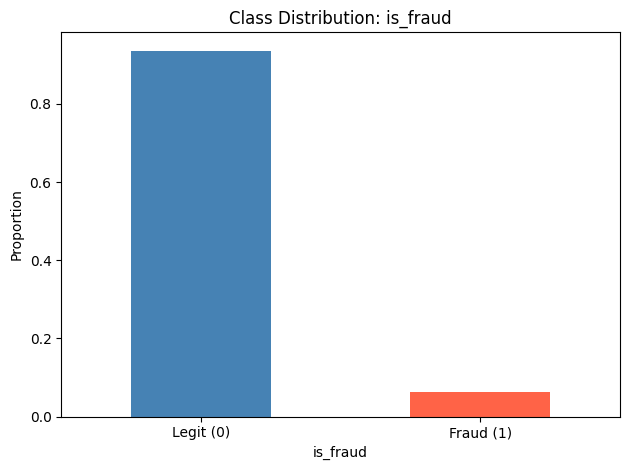

In [23]:
# Inspect the orders table and check class balance
print(orders.info())
print()

# Fraud rate â€” shows heavy class imbalance
fraud_counts = orders['is_fraud'].value_counts()
fraud_pct    = orders['is_fraud'].value_counts(normalize=True)

print('Fraud distribution:')
print(pd.DataFrame({'count': fraud_counts, 'pct': fraud_pct.round(4)}))

# Bar chart of class distribution
fraud_pct.plot(kind='bar', color=['steelblue','tomato'])
plt.title('Class Distribution: is_fraud')
plt.ylabel('Proportion')
plt.xticks([0, 1], ['Legit (0)', 'Fraud (1)'], rotation=0)
plt.tight_layout()
plt.show()

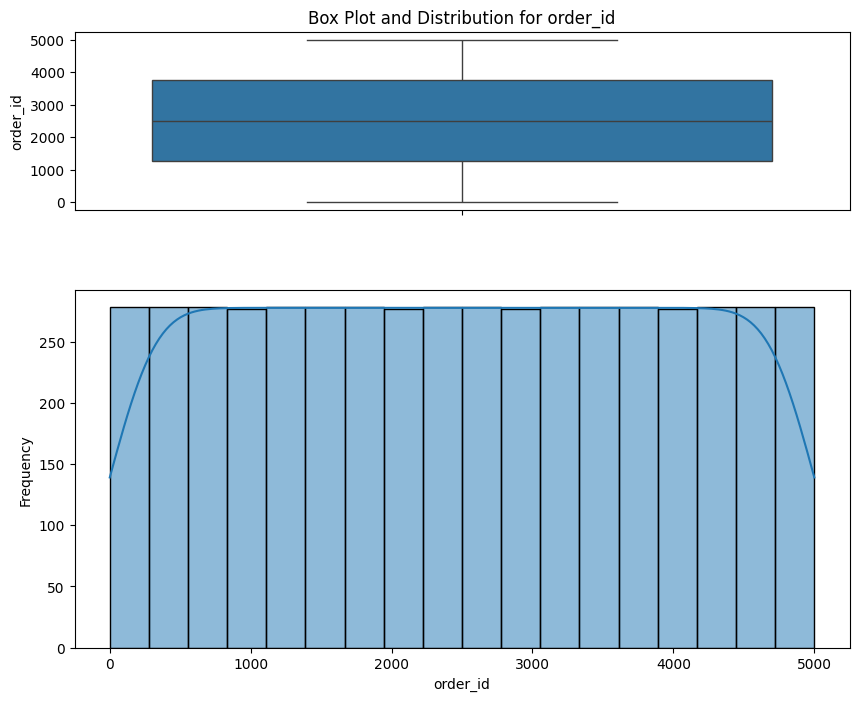

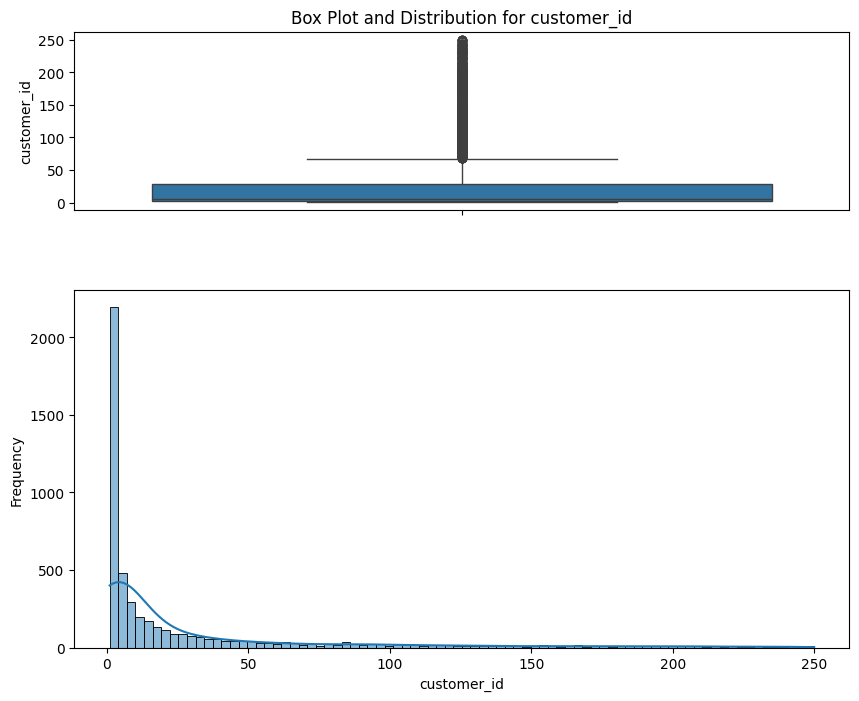

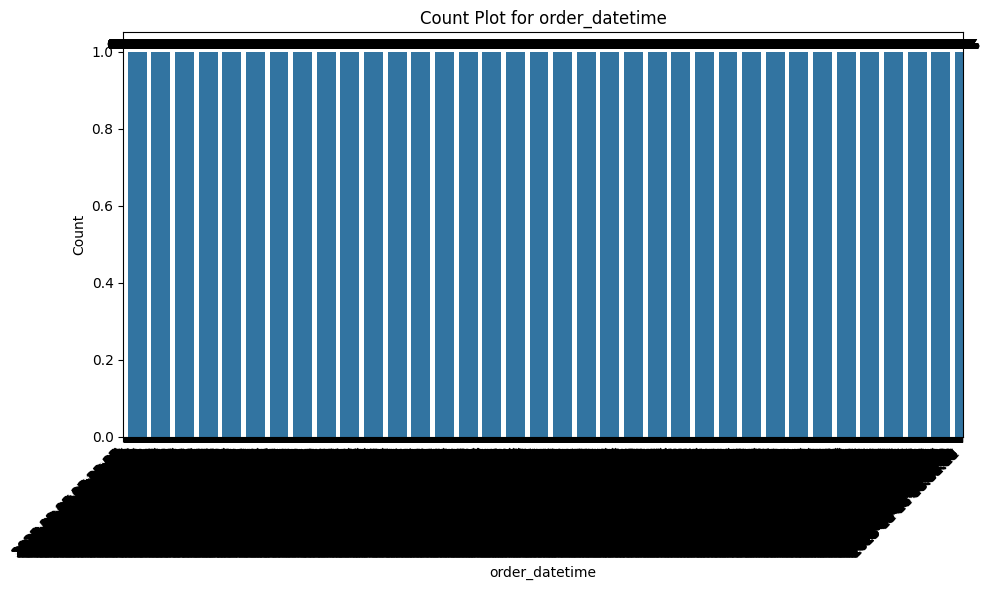

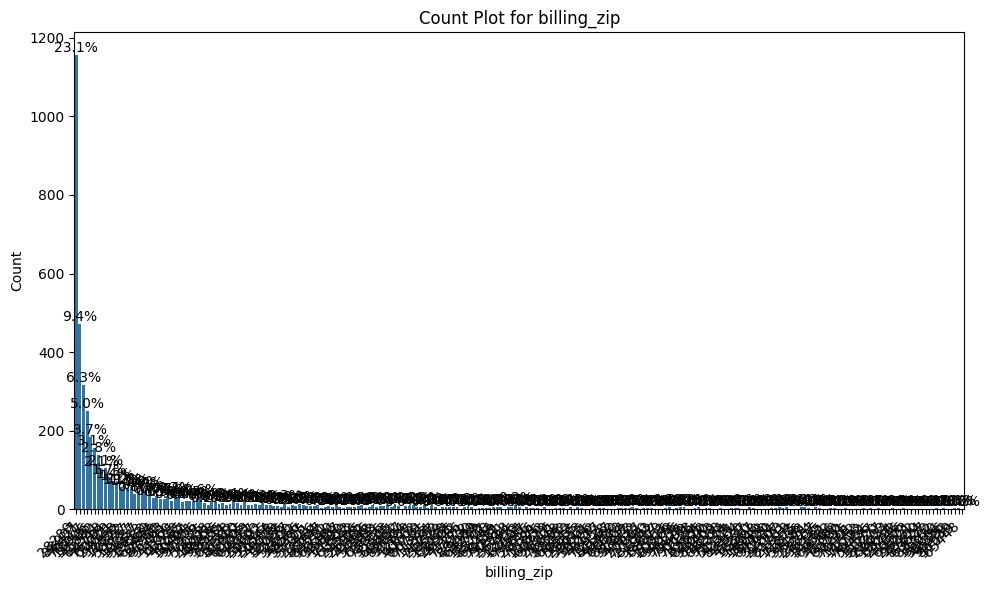

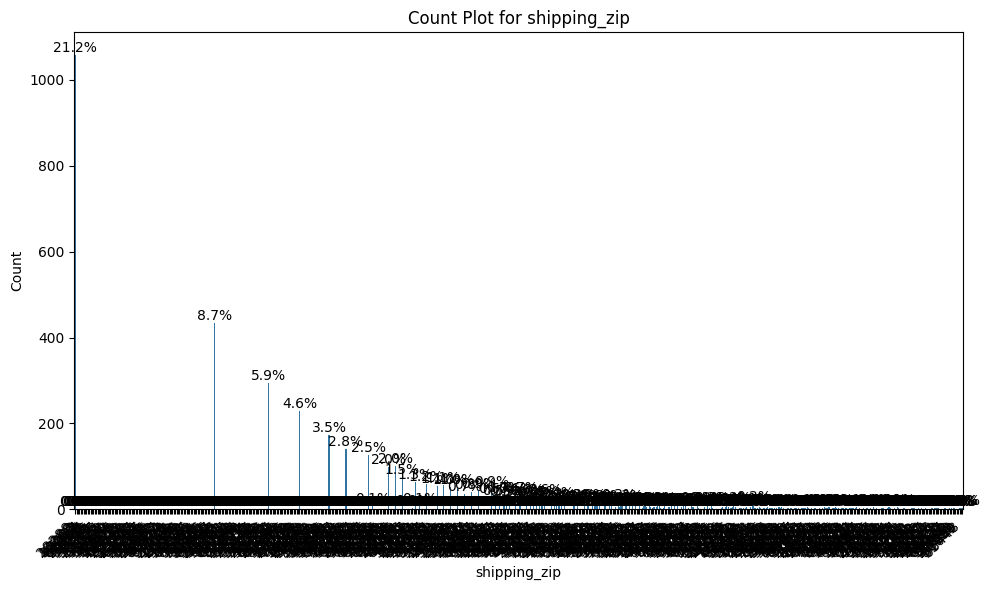

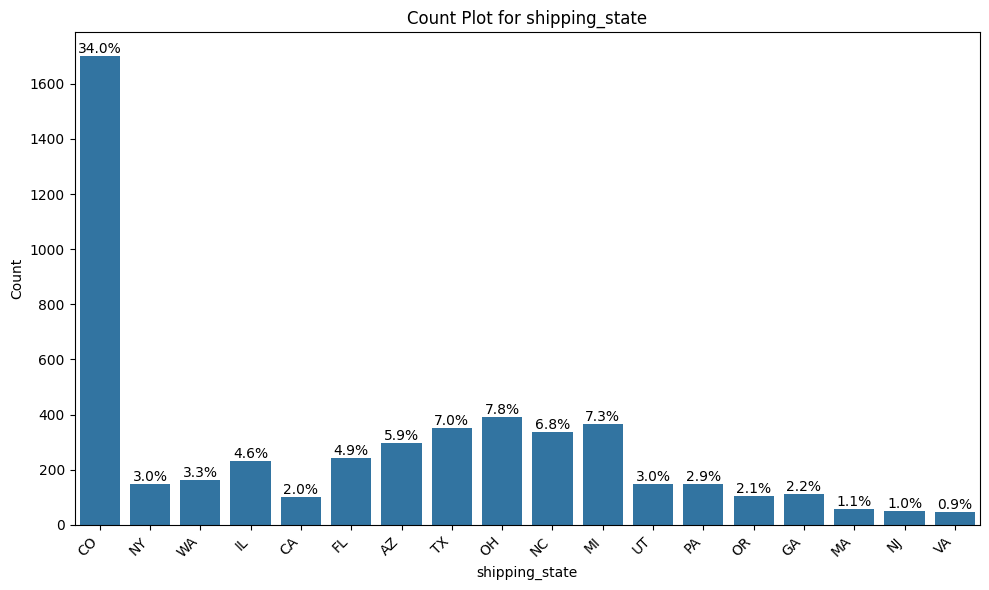

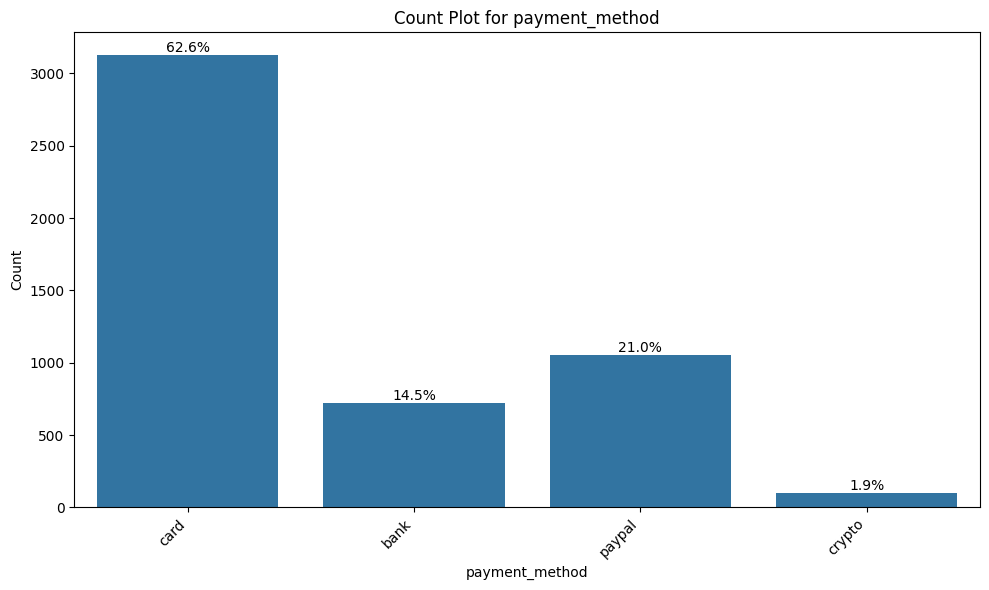

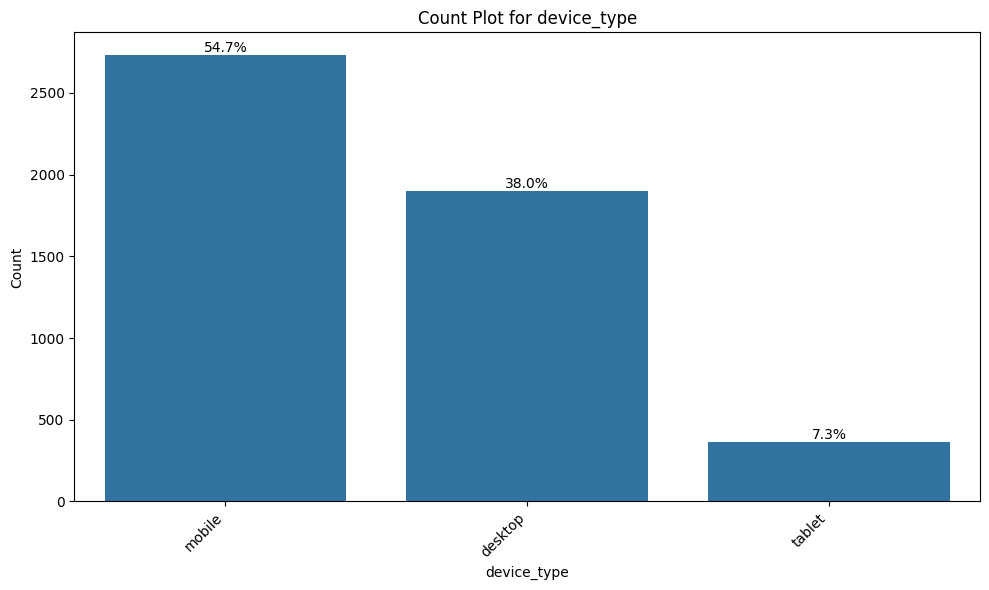

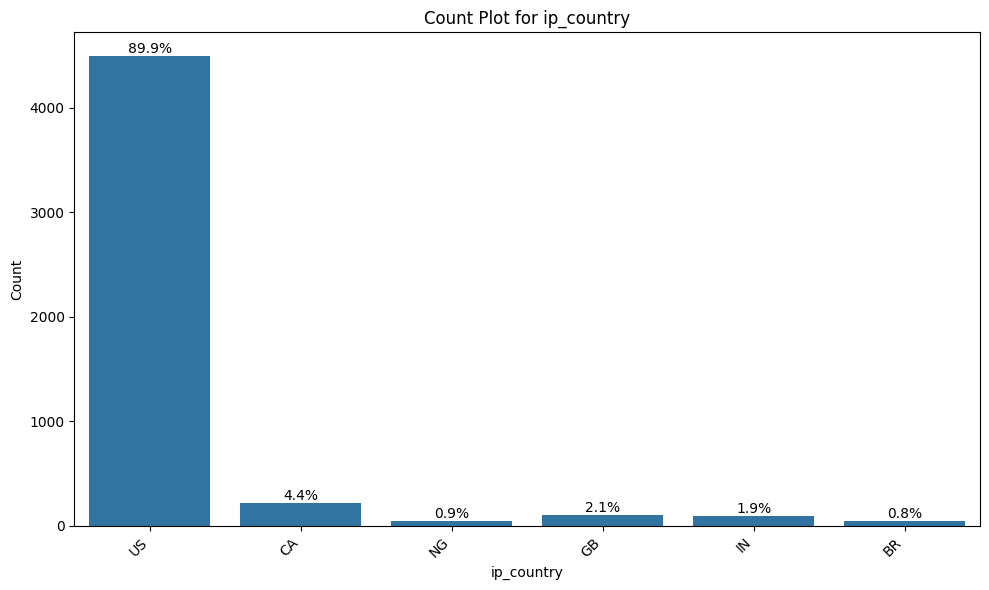

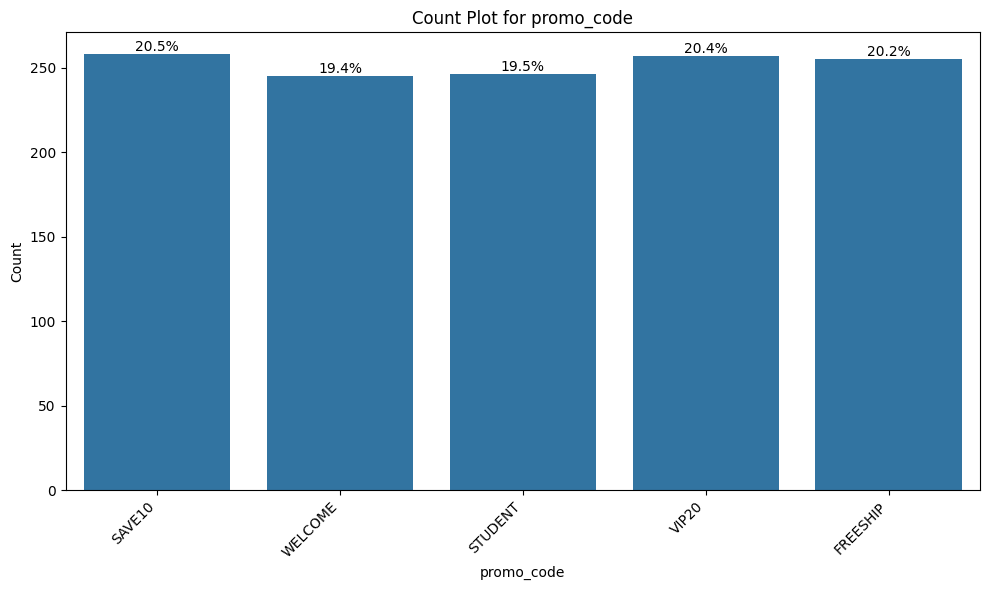

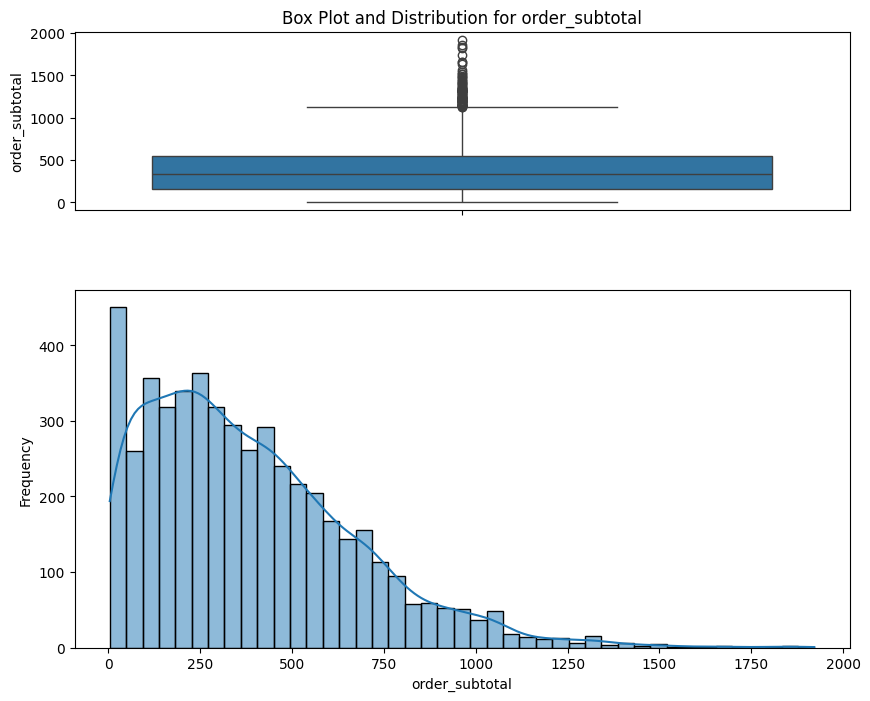

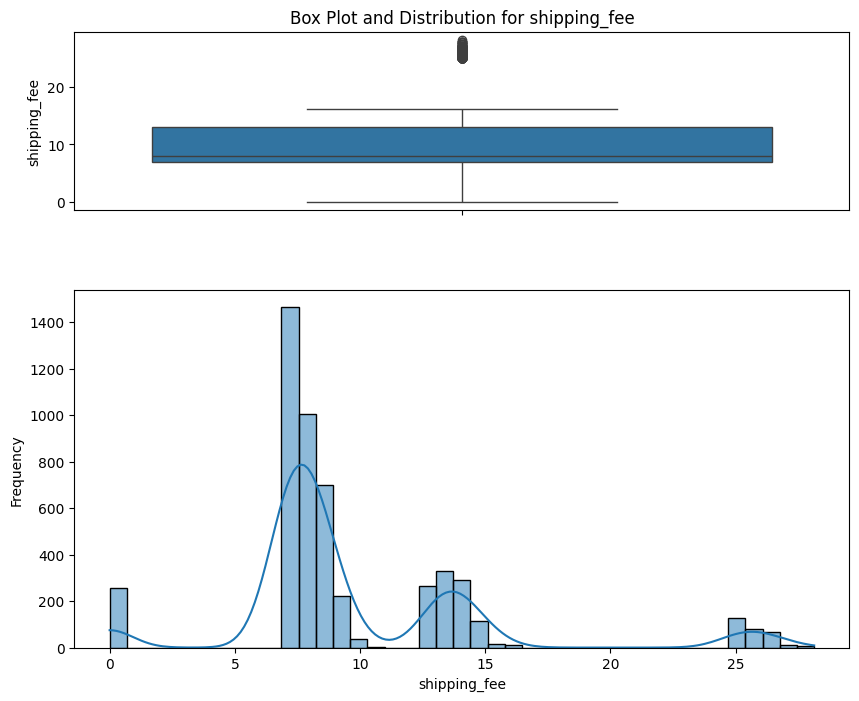

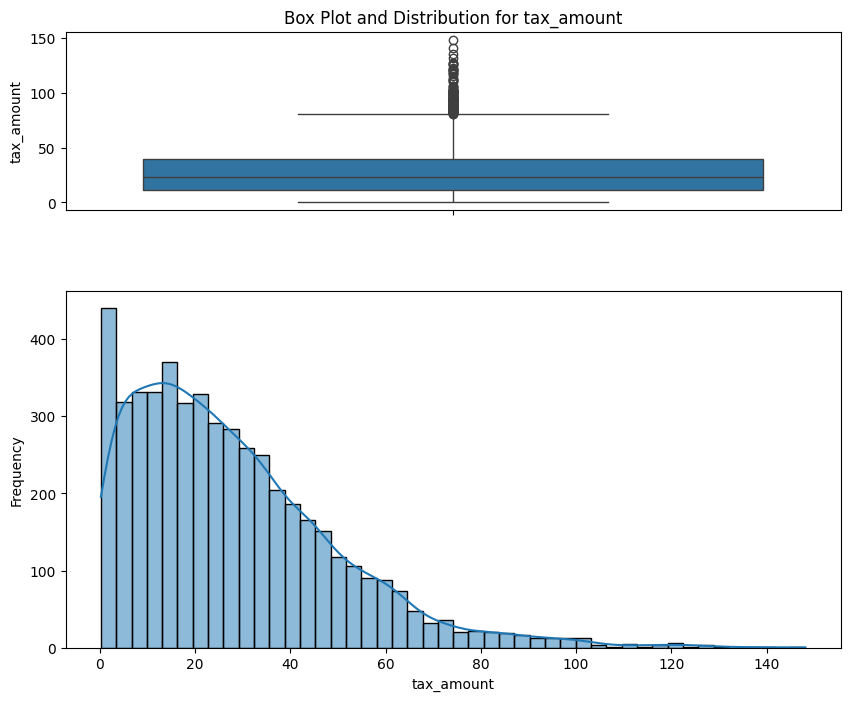

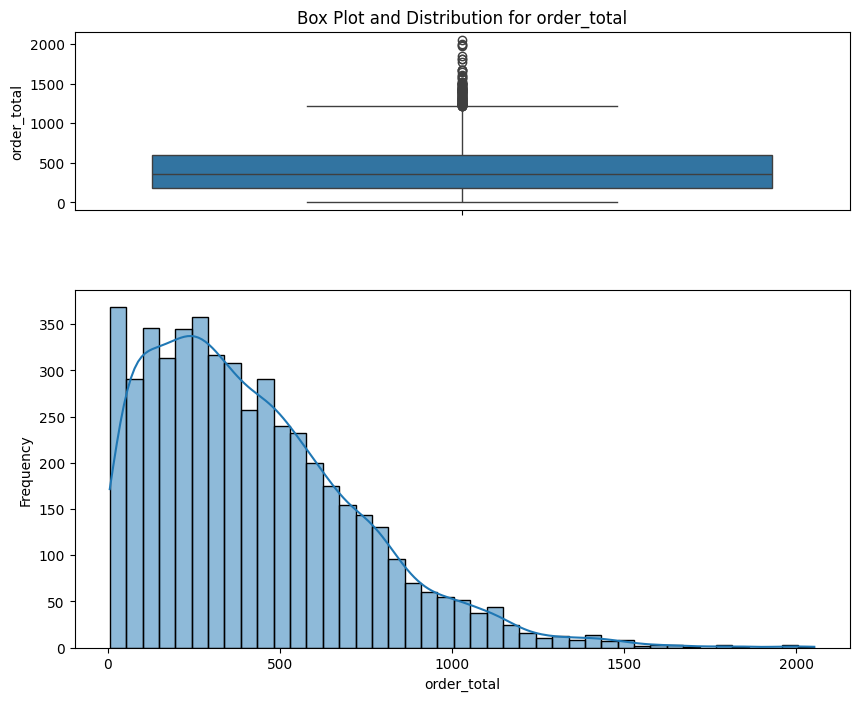

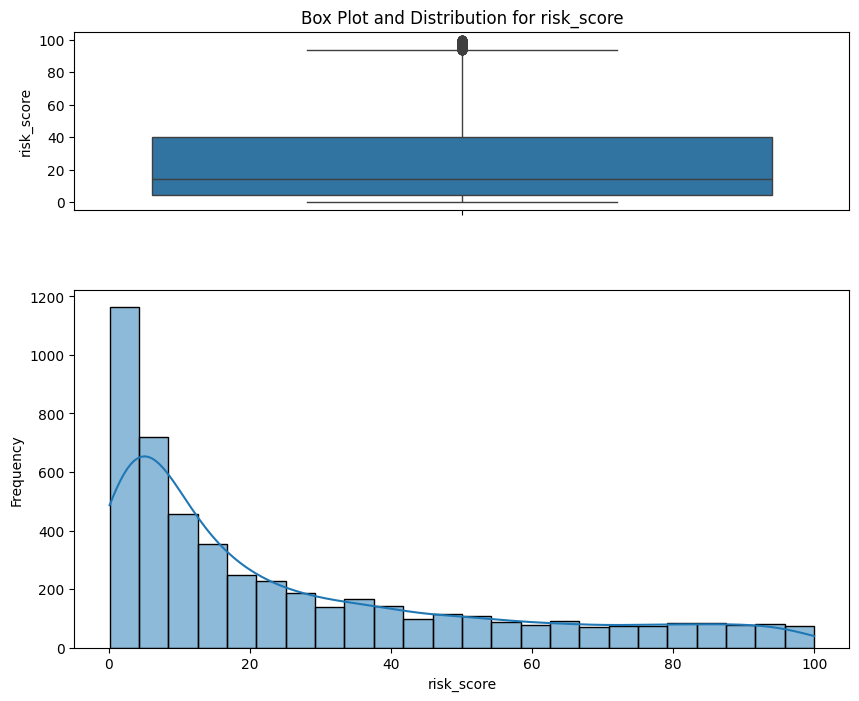

,Data Type,Count,Missing,Unique,Mode,Min,Q1,Median,Q3,Max,Mean,Std,Skew,Kurt
order_id,int64,5000,0,5000,1,1,1250.75,2500.5,3750.25,5000,2500.5,1443.520003,0.0,-1.2
customer_id,int64,5000,0,243,1,1,2.0,6.0,28.0,250,28.4482,49.086939,2.457298,5.673519
order_datetime,object,5000,0,5000,2025-07-09 17:11:18,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
billing_zip,object,5000,0,243,28289,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
shipping_zip,object,5000,0,630,28289,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
shipping_state,object,5000,0,18,CO,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
payment_method,object,5000,0,4,card,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
device_type,object,5000,0,3,mobile,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
ip_country,object,5000,0,6,US,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
promo_used,int64,5000,0,2,0,0,0.0,0.0,1.0,1,0.2522,0.434319,1.141554,-0.697134


In [24]:
# Feature-level exploration of the orders table using our custom function (Ch. 6)
# Returns a stats table; plots distributions for each column automatically
stats_table = univariate(orders)
display(stats_table)

## Phase 3: Data Preparation (Ch. 2â€“4, 7)

In [25]:
# Aggregate order_items to one row per order
items_agg = items_raw.groupby('order_id').agg(
    num_items       = ('quantity',   'sum'),
    num_products    = ('product_id', 'nunique'),
    avg_unit_price  = ('unit_price', 'mean')
).reset_index()

# Join orders with customers, aggregated items, and shipment info
df = (
    orders
    .merge(
        customers[['customer_id','birthdate','created_at','gender',
                   'customer_segment','loyalty_tier','state']],
        on='customer_id', how='left'
    )
    .merge(items_agg, on='order_id', how='left')
    .merge(
        shipments[['order_id','late_delivery','shipping_method','carrier','distance_band']],
        on='order_id', how='left'
    )
)

# Compute age and account tenure before dropping the raw date strings
order_dt    = pd.to_datetime(df['order_datetime'])
df['customer_age']       = ((order_dt - pd.to_datetime(df['birthdate'])).dt.days // 365)
df['account_tenure_days'] = (order_dt - pd.to_datetime(df['created_at'])).dt.days

# Binary flags derived from existing columns
df['billing_eq_shipping'] = (df['billing_zip'] == df['shipping_zip']).astype(int)
df['is_foreign_ip']       = (df['ip_country'] != 'US').astype(int)

# Drop ID and raw date columns we no longer need
# Also drop billing_zip/shipping_zip before manage_dates to prevent mis-parsing as dates
# Drop risk_score â€” it is a system-computed causal signal, not a raw behavioral feature
df.drop(columns=[
    'order_id', 'customer_id',
    'billing_zip', 'shipping_zip',
    'birthdate', 'created_at',
    'risk_score'
], inplace=True)

print(f'Shape after join and feature engineering: {df.shape}')
df.head(3)

Shape after join and feature engineering: (5000, 27)


,order_datetime,shipping_state,payment_method,device_type,ip_country,promo_used,promo_code,order_subtotal,shipping_fee,tax_amount,...,num_products,avg_unit_price,late_delivery,shipping_method,carrier,distance_band,customer_age,account_tenure_days,billing_eq_shipping,is_foreign_ip
0,2025-11-29 00:51:07,CO,card,mobile,US,0,None,662.95,15.44,46.30,...,5,69.242,1,expedited,UPS,regional,20,48,1,0
1,2025-09-01 10:25:59,NY,card,desktop,US,1,SAVE10,862.92,14.74,66.61,...,5,133.300,1,expedited,FedEx,local,20,-41,0,0
2,2025-12-15 07:24:41,CO,card,mobile,US,0,None,796.09,14.04,40.72,...,3,140.850,1,expedited,FedEx,national,20,64,1,0


In [26]:
# Extract date components from order_datetime using our custom function (Ch. 7)
# Adds columns: order_datetime_hour, _weekday, _month, _year, _day
df = manage_dates(df)

# Drop the original datetime string â€” components are already extracted
df.drop(columns=['order_datetime'], inplace=True)

print(f'Shape after date parsing: {df.shape}')
print('New date columns:', [c for c in df.columns if 'order_datetime' in c])

Shape after date parsing: (5000, 31)
New date columns: ['order_datetime_day', 'order_datetime_weekday', 'order_datetime_month', 'order_datetime_year', 'order_datetime_hour']


In [27]:
# Handle missing data using our custom function (Ch. 7)
# promo_code is 74.78% null and will be dropped; promo_used (binary) already captures this
df, missing_report = handle_missing_data(
    df, col_threshold=0.5, row_threshold=0.6, test_mechanism=True
)

print('\nColumns dropped:', missing_report['columns_dropped'])
print('Missing mechanism detected:', missing_report['missing_mechanism'])
print('Recommendations:')
for r in missing_report['recommendations']:
    print(' -', r)

Processing 31 columns...
Original shape: (5000, 31)
Dropping column 'promo_code': 74.8% missing (threshold: 50.0%)
Cleaned shape: (5000, 30)
Total columns dropped: 1
Total rows dropped: 0

Testing missing data mechanism...
No missing data found in dataframe.

Detected missing data mechanism: NO_MISSING

Recommendations:
  1. Unable to definitively determine missing data mechanism
  2. Use conservative approach: try multiple imputation methods and compare results
  3. Consider domain knowledge to understand missingness patterns
  4. Never impute missing values in your outcome/target variable (y)
  5. Always validate imputation results and compare with complete case analysis

Columns dropped: ['promo_code']
Missing mechanism detected: NO_MISSING
Recommendations:
 - Unable to definitively determine missing data mechanism
 - Use conservative approach: try multiple imputation methods and compare results
 - Consider domain knowledge to understand missingness patterns
 - Never impute missing 

In [28]:
# Drop any remaining object columns where every value is unique (e.g. free-text IDs)
before = df.shape[1]
df = basic_wrangling(df)
print(f'Columns removed by basic_wrangling: {before - df.shape[1]}')
print(f'Shape: {df.shape}')

Columns removed by basic_wrangling: 0
Shape: (5000, 30)


In [29]:
# Bin rare category values (< 5% of rows) into 'Other' to reduce noise (Ch. 7)
# Affects ip_country, state, and similar columns with long tails
df = bin_categories(df)

# Confirm remaining categorical values
cat_cols_check = df.select_dtypes('object').columns
for col in cat_cols_check:
    print(f'{col}: {df[col].value_counts().to_dict()}')

shipping_state: {'CO': 1702, 'Other': 1557, 'OH': 390, 'MI': 367, 'TX': 350, 'NC': 338, 'AZ': 296}
payment_method: {'card': 3128, 'paypal': 1050, 'bank': 725, 'Other': 97}
device_type: {'mobile': 2734, 'desktop': 1902, 'tablet': 364}
ip_country: {'US': 4496, 'Other': 504}
gender: {'Female': 2994, 'Male': 1832, 'Other': 174}
customer_segment: {'standard': 2890, 'budget': 1764, 'premium': 346}
loyalty_tier: {'silver': 2220, 'none': 1930, 'gold': 850}
state: {'CO': 1810, 'Other': 1429, 'OH': 417, 'MI': 397, 'NC': 368, 'TX': 306, 'AZ': 273}
shipping_method: {'standard': 3618, 'expedited': 1079, 'overnight': 303}
carrier: {'UPS': 2298, 'FedEx': 1705, 'USPS': 997}
distance_band: {'regional': 2294, 'local': 1716, 'national': 990}


In [30]:
# Use our normalize function to visualize skewness in numeric features (Ch. 7)
# We run it here for understanding only â€” sklearn's StandardScaler handles this in the pipeline
numeric_feats = df.drop(columns=['is_fraud']).select_dtypes('number').columns.tolist()
_ = normalize(df[numeric_feats])


Processing column 'promo_used':
  Original skewness: 1.1416
  Best transformation: sqrt (skewness: 1.1412)
  Added transformed column: 'promo_used_sqrt'

Processing column 'order_subtotal':
  Original skewness: 1.0459
  Best transformation: sqrt (skewness: 0.0380)
  Added transformed column: 'order_subtotal_sqrt'

Processing column 'shipping_fee':
  Original skewness: 1.5436
  Best transformation: sqrt (skewness: 0.0017)
  Added transformed column: 'shipping_fee_sqrt'

Processing column 'tax_amount':
  Original skewness: 1.2469
  Best transformation: yeojohnson (skewness: -0.0604)
  Added transformed column: 'tax_amount_yeojohnson'

Processing column 'order_total':
  Original skewness: 1.0471
  Best transformation: yeojohnson (skewness: -0.0797)
  Added transformed column: 'order_total_yeojohnson'

Processing column 'num_items':
  Original skewness: 0.4043
  Best transformation: yeojohnson (skewness: -0.0601)
  Added transformed column: 'num_items_yeojohnson'
Column 'num_products' alr

In [31]:
# Identify outliers â€” but do NOT remove them (Ch. 7)
# Outliers in order amounts or behavior patterns may be fraud signals
_ = manage_outliers(
    df.drop(columns=['is_fraud']),
    drop_outliers=False,
    verbose=True
)

Using 18 features for outlier detection:
  Features: promo_used, order_subtotal, shipping_fee, tax_amount, order_total, num_items, num_products, avg_unit_price, late_delivery, customer_age, account_tenure_days, billing_eq_shipping, is_foreign_ip, order_datetime_day, order_datetime_weekday, order_datetime_month, order_datetime_year, order_datetime_hour
  DBSCAN parameters: eps=0.5, min_samples=5

Valid rows (no missing values in features): 5000 / 5000

DBSCAN Results:
  Number of clusters found: 0
  Number of outliers detected: 5000
  Percentage of outliers: 100.00%

Top 5 columns contributing to outliers (by mean z-score):
  promo_used: Mean Z-Score = 0.000, Max Z-Score = 0.000
  order_subtotal: Mean Z-Score = 0.000, Max Z-Score = 0.000
  shipping_fee: Mean Z-Score = 0.000, Max Z-Score = 0.000
  tax_amount: Mean Z-Score = 0.000, Max Z-Score = 0.000
  order_total: Mean Z-Score = 0.000, Max Z-Score = 0.000

Outliers marked but not dropped. Use '_is_outlier' column to filter.


Mean feature values by fraud label:


,order_total,customer_age,account_tenure_days,num_items,avg_unit_price
is_fraud,,,,,
0,405.15,31.40,80.15,4.03,91.84
1,663.00,27.45,31.70,5.31,113.40


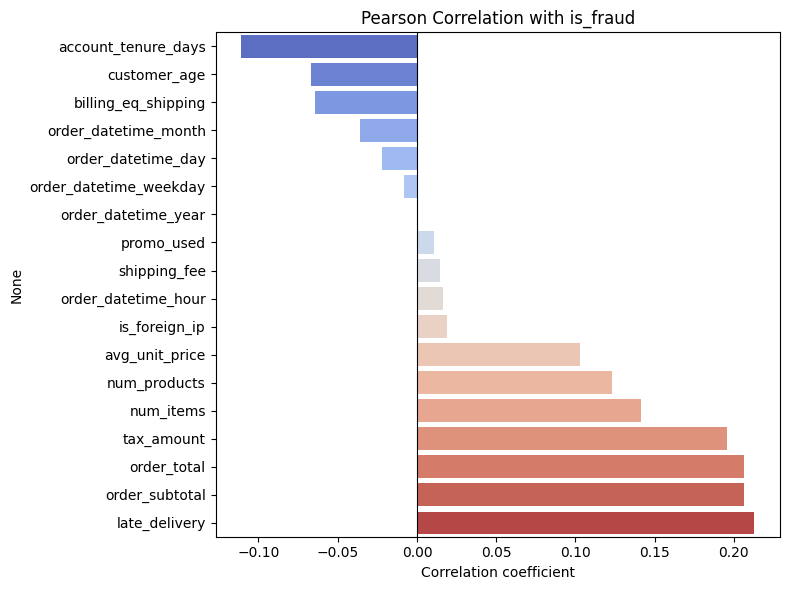

In [32]:
# Explore relationships between features and the fraud label (Ch. 8)

# Mean numeric feature values by fraud label
print('Mean feature values by fraud label:')
display(
    df.groupby('is_fraud')[[
        'order_total','customer_age','account_tenure_days',
        'num_items','avg_unit_price'
    ]].mean().round(2)
)

# Correlation of all numeric features with is_fraud
corr = df.select_dtypes('number').corr()['is_fraud'].drop('is_fraud').sort_values()

plt.figure(figsize=(8, 6))
sns.barplot(x=corr.values, y=corr.index, palette='coolwarm')
plt.axvline(0, color='black', linewidth=0.8)
plt.title('Pearson Correlation with is_fraud')
plt.xlabel('Correlation coefficient')
plt.tight_layout()
plt.show()

## Phase 4: Modeling (Ch. 11, 13, 14)

In [33]:
# Separate features and target
X = df.drop(columns=['is_fraud'])
y = df['is_fraud']

# Stratified split preserves the 6.4% fraud rate in both train and test sets (Ch. 13)
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.20, random_state=42, stratify=y
)

# Identify numeric and categorical columns for the preprocessing pipeline
num_cols = X_train.select_dtypes(include=['int64','float64']).columns.tolist()
cat_cols = X_train.select_dtypes(include=['object']).columns.tolist()

print(f'Train: {X_train.shape}, Test: {X_test.shape}')
print(f'Fraud rate â€” train: {y_train.mean():.3f}, test: {y_test.mean():.3f}')
print(f'Numeric cols ({len(num_cols)}): {num_cols}')
print(f'Categorical cols ({len(cat_cols)}): {cat_cols}')

Train: (4000, 29), Test: (1000, 29)
Fraud rate â€” train: 0.064, test: 0.064
Numeric cols (13): ['promo_used', 'order_subtotal', 'shipping_fee', 'tax_amount', 'order_total', 'num_items', 'num_products', 'avg_unit_price', 'late_delivery', 'customer_age', 'account_tenure_days', 'billing_eq_shipping', 'is_foreign_ip']
Categorical cols (11): ['shipping_state', 'payment_method', 'device_type', 'ip_country', 'gender', 'customer_segment', 'loyalty_tier', 'state', 'shipping_method', 'carrier', 'distance_band']


In [34]:
# Build a reusable preprocessing pipeline (Ch. 11)
# Numeric: fill missing with median, then scale to zero mean / unit variance
# Categorical: fill missing with most common value, then one-hot encode

numeric_pipe = Pipeline([
    ('imputer', SimpleImputer(strategy='median')),
    ('scaler',  StandardScaler())
])

categorical_pipe = Pipeline([
    ('imputer', SimpleImputer(strategy='most_frequent')),
    ('onehot',  OneHotEncoder(handle_unknown='ignore', sparse_output=False))
])

preprocessor = ColumnTransformer([
    ('num', numeric_pipe,     num_cols),
    ('cat', categorical_pipe, cat_cols)
])

In [35]:
# Define four classifiers â€” each wraps the same preprocessor (Ch. 13â€“14)
# class_weight='balanced' compensates for the 6.4% fraud minority class

# Logistic Regression baseline (Ch. 13)
model_lr = Pipeline([
    ('prep', preprocessor),
    ('clf',  LogisticRegression(max_iter=1000, class_weight='balanced', random_state=42))
])

# Decision Tree â€” interpretable, single tree (Ch. 13)
model_dt = Pipeline([
    ('prep', preprocessor),
    ('clf',  DecisionTreeClassifier(max_depth=6, class_weight='balanced', random_state=42))
])

# Random Forest â€” bagging ensemble of trees (Ch. 14)
model_rf = Pipeline([
    ('prep', preprocessor),
    ('clf',  RandomForestClassifier(
        n_estimators=200, class_weight='balanced', random_state=42, n_jobs=-1
    ))
])

# Gradient Boosting â€” sequential boosting ensemble (Ch. 14)
model_gb = Pipeline([
    ('prep', preprocessor),
    ('clf',  GradientBoostingClassifier(
        n_estimators=200, learning_rate=0.05, max_depth=3, random_state=42
    ))
])

models = [('Logistic Regression', model_lr),
          ('Decision Tree',       model_dt),
          ('Random Forest',       model_rf),
          ('Gradient Boosting',   model_gb)]

# Fit all models on the training set
for name, model in models:
    model.fit(X_train, y_train)
    print(f'{name} â€” trained')

Logistic Regression â€” trained
Decision Tree â€” trained
Random Forest â€” trained
Gradient Boosting â€” trained


## Phase 5: Evaluation, Selection & Tuning (Ch. 15)

In [36]:
# Compare models using 5-fold stratified cross-validation on the training set (Ch. 15)
# Stratified folds maintain the fraud class ratio across each fold

skf = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

scoring = {
    'roc_auc':   'roc_auc',
    'recall':    'recall',
    'precision': 'precision',
    'f1':        'f1'
}

cv_results = {}
for name, model in models:
    cv = cross_validate(model, X_train, y_train, cv=skf, scoring=scoring, n_jobs=-1)
    cv_results[name] = {
        'ROC-AUC':   cv['test_roc_auc'].mean(),
        'Recall':    cv['test_recall'].mean(),
        'Precision': cv['test_precision'].mean(),
        'F1':        cv['test_f1'].mean()
    }

cv_df = pd.DataFrame(cv_results).T.round(3)
cv_df = cv_df.sort_values('ROC-AUC', ascending=False)
print('Cross-validation results (mean over 5 folds):')
display(cv_df)

Cross-validation results (mean over 5 folds):


,ROC-AUC,Recall,Precision,F1
Logistic Regression,0.859,0.827,0.184,0.301
Gradient Boosting,0.855,0.027,0.237,0.049
Random Forest,0.824,0.004,0.100,0.008
Decision Tree,0.777,0.760,0.161,0.266


Best model: Logistic Regression

Classification Report:
              precision    recall  f1-score   support

       Legit       0.98      0.74      0.84       936
       Fraud       0.18      0.81      0.29        64

    accuracy                           0.74      1000
   macro avg       0.58      0.78      0.57      1000
weighted avg       0.93      0.74      0.81      1000



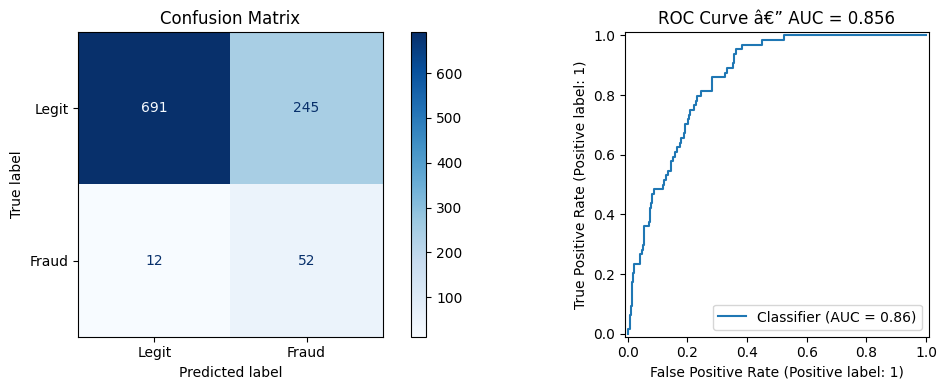

In [37]:
# Evaluate the best model (highest CV ROC-AUC) on the held-out test set
# The test set was never used during training or cross-validation

best_name  = cv_df.index[0]
best_model = dict(models)[best_name]
print(f'Best model: {best_name}')

y_pred = best_model.predict(X_test)
y_prob = best_model.predict_proba(X_test)[:, 1]

print('\nClassification Report:')
print(classification_report(y_test, y_pred, target_names=['Legit', 'Fraud']))

# Confusion matrix
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

ConfusionMatrixDisplay.from_predictions(
    y_test, y_pred, display_labels=['Legit','Fraud'], cmap='Blues', ax=axes[0]
)
axes[0].set_title('Confusion Matrix')

# ROC curve
RocCurveDisplay.from_predictions(y_test, y_prob, ax=axes[1])
axes[1].set_title(f'ROC Curve â€” AUC = {roc_auc_score(y_test, y_prob):.3f}')

plt.tight_layout()
plt.show()

In [38]:
# Tune the best model using GridSearchCV (Ch. 15)
# Parameter grid depends on which model won â€” defaulting to Random Forest params

if 'Random Forest' in best_name:
    param_grid = {
        'clf__n_estimators':    [100, 200],
        'clf__max_depth':       [None, 5, 10],
        'clf__min_samples_leaf': [1, 3]
    }
elif 'Gradient' in best_name:
    param_grid = {
        'clf__n_estimators':  [100, 200],
        'clf__learning_rate': [0.05, 0.1],
        'clf__max_depth':     [2, 3, 5]
    }
elif 'Logistic' in best_name:
    param_grid = {
        'clf__C':       [0.01, 0.1, 1.0, 10.0],
        'clf__penalty': ['l1', 'l2'],
        'clf__solver':  ['liblinear']
    }
else:  # Decision Tree
    param_grid = {
        'clf__max_depth':        [3, 5, 6, 8, None],
        'clf__min_samples_leaf': [1, 3, 5]
    }

grid = GridSearchCV(
    best_model, param_grid, cv=skf, scoring='roc_auc', n_jobs=-1, verbose=1
)
grid.fit(X_train, y_train)

print('Best parameters:', grid.best_params_)
print(f'Best CV AUC:    {grid.best_score_:.4f}')

# Replace best_model with the tuned version
best_model = grid.best_estimator_

Fitting 5 folds for each of 8 candidates, totalling 40 fits
Best parameters: {'clf__C': 0.1, 'clf__penalty': 'l1', 'clf__solver': 'liblinear'}
Best CV AUC:    0.8646


## Phase 6: Feature Selection (Ch. 16)

In [39]:
# SelectFromModel: use a Gradient Boosting model's feature importances
# to keep only features with above-average importance (Ch. 16)
# This is evaluated inside cross-validation to prevent data leakage

gb_with_selection = Pipeline([
    ('prep',   preprocessor),
    ('select', SelectFromModel(
        GradientBoostingClassifier(n_estimators=100, random_state=42),
        threshold='mean'
    )),
    ('clf',    GradientBoostingClassifier(
        n_estimators=200, learning_rate=0.05, max_depth=3, random_state=42
    ))
])

cv_selected = cross_validate(
    gb_with_selection, X_train, y_train, cv=skf, scoring=scoring, n_jobs=-1
)

print(f'Gradient Boosting (all features) AUC:      {cv_results["Gradient Boosting"]["ROC-AUC"]:.4f}')
print(f'Gradient Boosting (selected features) AUC: {cv_selected["test_roc_auc"].mean():.4f}')

Gradient Boosting (all features) AUC:      0.8555
Gradient Boosting (selected features) AUC: 0.8602


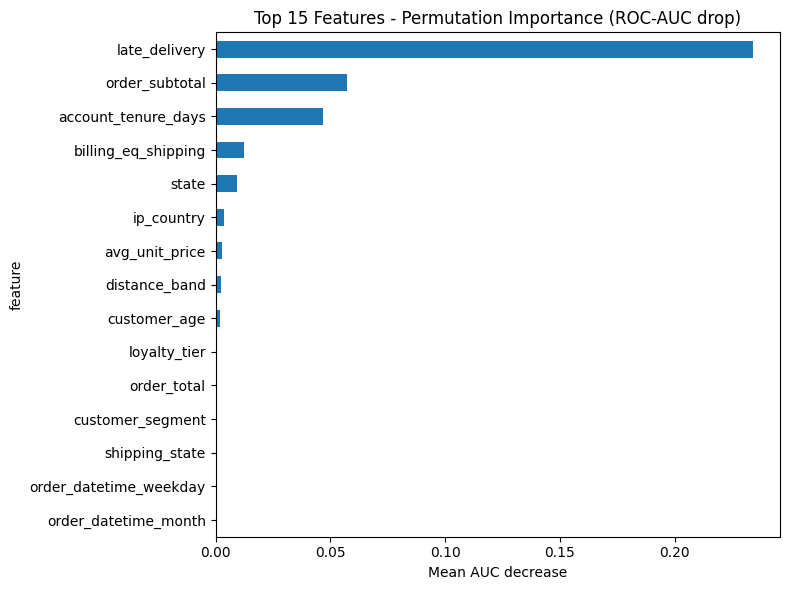

In [40]:
# Permutation feature importance on the test set (Ch. 16)
# Shows how much model performance drops when each feature is randomly shuffled

best_model.fit(X_train, y_train)   # re-fit in case grid search changed it

perm = permutation_importance(
    best_model, X_test, y_test,
    n_repeats=10, random_state=42, n_jobs=-1, scoring="roc_auc"
)

# permutation_importance shuffles raw input columns, so names come from X_test --
# not get_feature_names_out(), which reflects post-encoding expanded columns
feat_names = X_test.columns.tolist()

importance_df = (
    pd.DataFrame({"feature": feat_names, "importance": perm.importances_mean})
    .sort_values("importance", ascending=False)
    .head(15)
)

importance_df.plot.barh(x="feature", y="importance", figsize=(8, 6), legend=False)
plt.title("Top 15 Features - Permutation Importance (ROC-AUC drop)")
plt.xlabel("Mean AUC decrease")
plt.gca().invert_yaxis()
plt.tight_layout()
plt.show()

## Phase 7: Deployment â€” Serialize & Inference (Ch. 17)

In [41]:
# Final fit on the full training set and save the pipeline with joblib (Ch. 17)
best_model.fit(X_train, y_train)
joblib.dump(best_model, 'fraud_model.sav')
print('Model saved â†’ fraud_model.sav')

Model saved â†’ fraud_model.sav


In [42]:
# Compute final test-set metrics and save metadata + metrics as JSON (Ch. 17)
y_pred_final = best_model.predict(X_test)
y_prob_final = best_model.predict_proba(X_test)[:, 1]

metadata = {
    'model_name':      'fraud_detection_pipeline',
    'best_model_type': best_name,
    'trained_at_utc':  datetime.utcnow().isoformat(),
    'n_train_rows':    int(X_train.shape[0]),
    'n_test_rows':     int(X_test.shape[0]),
    'features':        X_train.columns.tolist()
}

metrics = {
    'roc_auc':          float(roc_auc_score(y_test, y_prob_final)),
    'recall_fraud':     float(recall_score(y_test, y_pred_final)),
    'precision_fraud':  float(precision_score(y_test, y_pred_final)),
    'f1_fraud':         float(f1_score(y_test, y_pred_final)),
    'accuracy':         float(accuracy_score(y_test, y_pred_final)),
    'classification_report': classification_report(
        y_test, y_pred_final,
        target_names=['Legit','Fraud'],
        output_dict=True
    )
}

with open('model_metadata.json', 'w') as f:
    json.dump(metadata, f, indent=2)

with open('metrics.json', 'w') as f:
    json.dump(metrics, f, indent=2)

print('Saved: model_metadata.json, metrics.json')
print(f'\nFinal test metrics:')
print(f'  ROC-AUC:   {metrics["roc_auc"]:.4f}')
print(f'  Recall:    {metrics["recall_fraud"]:.4f}')
print(f'  Precision: {metrics["precision_fraud"]:.4f}')
print(f'  F1:        {metrics["f1_fraud"]:.4f}')

Saved: model_metadata.json, metrics.json

Final test metrics:
  ROC-AUC:   0.8593
  Recall:    0.8281
  Precision: 0.1732
  F1:        0.2865


In [43]:
# Demonstrate inference: load the saved model and score new orders (Ch. 17)
# In production this cell would run on fresh data pulled from the database

loaded_model = joblib.load('fraud_model.sav')

# Pull a small batch of orders to score (simulating live data)
conn = sqlite3.connect('shop.db')
new_orders = pd.read_sql("SELECT * FROM orders LIMIT 20", conn)
new_customers = pd.read_sql("SELECT * FROM customers", conn)
new_items = pd.read_sql("SELECT * FROM order_items", conn)
new_shipments = pd.read_sql("SELECT * FROM shipments", conn)
conn.close()

# Apply the same feature engineering used during training
new_items_agg = new_items.groupby('order_id').agg(
    num_items      = ('quantity',   'sum'),
    num_products   = ('product_id', 'nunique'),
    avg_unit_price = ('unit_price', 'mean')
).reset_index()

new_df = (
    new_orders
    .merge(
        new_customers[['customer_id','birthdate','created_at','gender',
                       'customer_segment','loyalty_tier','state']],
        on='customer_id', how='left'
    )
    .merge(new_items_agg, on='order_id', how='left')
    .merge(
        new_shipments[['order_id','late_delivery','shipping_method','carrier','distance_band']],
        on='order_id', how='left'
    )
)

order_dt = pd.to_datetime(new_df['order_datetime'])
new_df['customer_age']        = ((order_dt - pd.to_datetime(new_df['birthdate'])).dt.days // 365)
new_df['account_tenure_days'] = (order_dt - pd.to_datetime(new_df['created_at'])).dt.days
new_df['billing_eq_shipping'] = (new_df['billing_zip'] == new_df['shipping_zip']).astype(int)
new_df['is_foreign_ip']       = (new_df['ip_country'] != 'US').astype(int)

new_df.drop(columns=[
    'order_id', 'customer_id', 'billing_zip', 'shipping_zip',
    'birthdate', 'created_at', 'risk_score'
], inplace=True)

new_df = manage_dates(new_df)
new_df.drop(columns=['order_datetime'], errors='ignore', inplace=True)

# Drop the target column from inference data if present
true_labels = new_df.pop('is_fraud') if 'is_fraud' in new_df.columns else None

# Drop columns that were removed during training (promo_code, etc.)
inference_cols = [c for c in new_df.columns if c in X_train.columns]
X_new = new_df[inference_cols].reindex(columns=X_train.columns)

# Score: probability of fraud and binary prediction
fraud_probs = loaded_model.predict_proba(X_new)[:, 1]
fraud_preds = loaded_model.predict(X_new)

results_df = pd.DataFrame({
    'fraud_probability': fraud_probs.round(4),
    'fraud_prediction':  fraud_preds,
    'actual_label':      true_labels.values if true_labels is not None else 'N/A'
})

print('Inference results for 20 sample orders:')
display(results_df)

Inference results for 20 sample orders:


,fraud_probability,fraud_prediction,actual_label
0,0.6981,1,0
1,0.9564,1,0
2,0.8457,1,1
3,0.0082,0,0
4,0.3148,0,0
5,0.7060,1,0
6,0.0341,0,0
7,0.6916,1,0
8,0.0634,0,0
9,0.0131,0,0
